# Section 3: Shared Leakage-Safe Pipeline, Feature Engineering & Boosting

**Student ID:** IT24102831  
**Technical Role:** Pipeline & Boosting  
**Module:** IT3091 Machine Learning | **Group:** 2026-DS-58  
**Dataset:** Ames Housing | **Target:** SalePrice | **Seed:** 42  

---

## Section Scope

This notebook serves as the group's **hard architectural checkpoint**: it constructs the single, shared, leakage-safe preprocessing pipeline on which all final models are trained.

1. **Clean Data Alignment:** Reloads the fixed train/test split from Notebook 01 and applies Notebook 02's outlier removal indices so all project models evaluate on identical training data.
2. **Domain-Driven Feature Engineering:** Introduces five domain-justified features (`TotalSF`, `HouseAge`, `RemodAge`, `TotalBath`, and `WasRemodeled`).
3. **Leakage-Safe Architecture:** Constructs an end-to-end `sklearn` `ColumnTransformer` + `Pipeline`, fitted **strictly on the training fold** to prevent test-set data leakage during imputation, scaling, and categorical encoding.
4. **Feature Ablation Study:** Evaluates gradient boosted tree performance with versus without engineered features to validate their inclusion.
5. **Advanced Model Suite:** Fits XGBoost, LightGBM, and CatBoost models using the shared pipeline, exporting out-of-fold predictions and fitted artifacts for final validation.

In [1]:
# Imports & Global Configuration
import os
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Pipeline & boosting environment initialized.")

Pipeline & boosting environment initialized.


In [2]:
def find_file(filename):
    for p in [Path(filename), Path(f"results/{filename}"), Path(f"/kaggle/input/{filename}")]:
        if p.exists():
            return p
    if Path("/kaggle/input").exists():
        found = list(Path("/kaggle/input").rglob(filename))
        if found:
            return found[0]
    return None

# --- Reload the raw data and reproduce the EXACT split from Role A ---
train_csv_path = find_file("train.csv")
if train_csv_path is None:
    raise FileNotFoundError("Could not find train.csv. Make sure the competition dataset is attached.")

df_raw = pd.read_csv(train_csv_path)
df_clean = df_raw.drop(columns=["Id"]) if "Id" in df_raw.columns else df_raw.copy()
X_all = df_clean.drop(columns=["SalePrice"])
y_all = df_clean["SalePrice"]

train_idx_path = find_file("train_indices.csv")
test_idx_path = find_file("test_indices.csv")
if train_idx_path is None or test_idx_path is None:
    raise FileNotFoundError("Could not find the fixed split from Notebook 01. Run Notebook 01 first.")

train_idx = pd.read_csv(train_idx_path).values.flatten()
test_idx = pd.read_csv(test_idx_path).values.flatten()

X_train_raw = X_all.iloc[train_idx].copy()
X_test_raw = X_all.iloc[test_idx].copy()
y_train_raw = y_all.iloc[train_idx].copy()
y_test = y_all.iloc[test_idx].copy()

# --- Apply Role B's outlier removal so everyone trains on the same cleaned data ---
removed_path = find_file("02_removed_outlier_indices.csv")
if removed_path is not None:
    removed_idx = pd.read_csv(removed_path)["removed_train_idx"].tolist()
    keep_mask = ~X_train_raw.index.isin(removed_idx)
    X_train_raw = X_train_raw.loc[keep_mask].copy()
    y_train_raw = y_train_raw.loc[keep_mask].copy()
    print(f"Applied Role B's outlier removal: dropped {len(removed_idx)} training row(s) (GrLivArea outliers).")
else:
    removed_idx = []
    print("WARNING: 02_removed_outlier_indices.csv not found -- proceeding WITHOUT outlier removal. "
          "Run Notebook 02 first for a consistent shared dataset.")

print(f"Train shape: {X_train_raw.shape} | Test shape: {X_test_raw.shape}")

Applied Role B's outlier removal: dropped 2 training row(s) (GrLivArea outliers).
Train shape: (1166, 79) | Test shape: (292, 79)


## 3.1 Feature Engineering

The engineered features are detailed below alongside their domain justifications:

| Feature | Formula | Justification |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | Buyers price total usable square footage rather than evaluating each floor independently. |
| `HouseAge` | `YrSold - YearBuilt` | Age directly captures physical depreciation and architectural era better than a raw construction year. |
| `RemodAge` | `YrSold - YearRemodAdd` | A recent remodel serves as a distinct valuation driver separate from the original build age. |
| `TotalBath` | `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath` | Consolidates four sparse bathroom variables into a single, highly interpretable total count for tree-based splits. |
| `WasRemodeled` | `YearRemodAdd != YearBuilt` | Explicitly flags properties with post-construction renovations independent of timing. |

In [3]:
def engineer_features(df):
    out = df.copy()

    def col(name, default=0):
        return out[name] if name in out.columns else default

    out["TotalSF"] = col("TotalBsmtSF") + col("1stFlrSF") + col("2ndFlrSF")
    out["HouseAge"] = (col("YrSold") - col("YearBuilt")).clip(lower=0)
    out["RemodAge"] = (col("YrSold") - col("YearRemodAdd")).clip(lower=0)
    out["TotalBath"] = (
        col("FullBath") + 0.5 * col("HalfBath")
        + col("BsmtFullBath") + 0.5 * col("BsmtHalfBath")
    )
    out["WasRemodeled"] = (col("YearRemodAdd") != col("YearBuilt")).astype(int)
    return out

X_train_fe = engineer_features(X_train_raw)
X_test_fe = engineer_features(X_test_raw)
engineered_cols = ["TotalSF", "HouseAge", "RemodAge", "TotalBath", "WasRemodeled"]

print("Engineered feature preview (training data):")
display(X_train_fe[engineered_cols].describe())

Engineered feature preview (training data):


,TotalSF,HouseAge,RemodAge,TotalBath,WasRemodeled
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,2571.127787,36.915952,22.961407,2.218268,0.485420
std,761.517011,30.691428,20.709585,0.774431,0.500002
min,334.000000,0.000000,0.000000,1.000000,0.000000
25%,2029.500000,7.000000,4.000000,2.000000,0.000000
50%,2491.500000,35.000000,14.000000,2.000000,0.000000
75%,3009.500000,55.000000,42.000000,2.500000,1.000000
max,6872.000000,136.000000,60.000000,6.000000,1.000000


## 3.2 Ordinal Quality Encoding (Bug-Fixed Version)

**Bug Fix Alignment:** Quality-based ordinal features are identified strictly by checking unique **column values** rather than matching substrings in column names. Pattern matching on name substrings (e.g., searching for `"Qual"` or `"Cond"`) incorrectly flags nominal variables such as `Condition1`, `Condition2`, and `SaleCondition`, silently converting their contents to missing values and zeroing them out. 

The updated logic verifies that a column's non-null unique values form a strict subset of the ordinal rating scale `{Ex, Gd, TA, Fa, Po}` before applying ordinal encoding.

In [4]:
QUAL_MAP = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}
QUAL_VALUE_SET = set(QUAL_MAP.keys())

def encode_quality_columns(df):
    out = df.copy()
    candidate_cols = out.select_dtypes(include=["object", "category"]).columns.tolist()
    if not candidate_cols:
        candidate_cols = [
            c for c in out.columns
            if pd.api.types.is_object_dtype(out[c]) or pd.api.types.is_string_dtype(out[c])
        ]
    qual_cols = [c for c in candidate_cols if set(out[c].dropna().unique()).issubset(QUAL_VALUE_SET)]
    for c in qual_cols:
        out[c] = out[c].map(QUAL_MAP)
    return out, qual_cols

X_train_fe, qual_cols = encode_quality_columns(X_train_fe)
X_test_fe, _ = encode_quality_columns(X_test_fe)
print("Quality columns treated as ordinal numeric (matched by VALUE, not name):", qual_cols)

Quality columns treated as ordinal numeric (matched by VALUE, not name): ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']


## 3.3 Shared Leakage-Safe Pipeline

A unified `ColumnTransformer` processes all remaining features:
* **Numeric Features** (including ordinal quality scores and engineered features): Imputed using training set medians.
* **Categorical Features**: Imputed using the most-frequent strategy and transformed via One-Hot Encoding (`handle_unknown="ignore"` to safely manage unseen categories during test-set evaluation).

To guarantee strict leakage prevention, the transformer is **fitted exclusively on `X_train_fe`** and subsequently applied without refitting to `X_test_fe`. The fitted pipeline artifact is serialized to `results/shared_preprocessor.joblib`, enabling downstream notebooks and validation steps to execute identical transformations.

In [5]:
numeric_cols = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_fe.columns if c not in numeric_cols]
print(f"{len(numeric_cols)} numeric columns, {len(categorical_cols)} categorical columns")

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

# Fit ONLY on training data -- this is the leakage-safe step
preprocessor.fit(X_train_fe)

X_train_final = pd.DataFrame(
    preprocessor.transform(X_train_fe),
    columns=preprocessor.get_feature_names_out(),
    index=X_train_fe.index,
)
X_test_final = pd.DataFrame(
    preprocessor.transform(X_test_fe),
    columns=preprocessor.get_feature_names_out(),
    index=X_test_fe.index,
)
print(f"Final shared feature matrix: train={X_train_final.shape}, test={X_test_final.shape}")

joblib.dump(preprocessor, RESULTS_DIR / "shared_preprocessor.joblib")
print("Saved fitted pipeline to results/shared_preprocessor.joblib")

51 numeric columns, 33 categorical columns
Final shared feature matrix: train=(1166, 255), test=(292, 255)
Saved fitted pipeline to results/shared_preprocessor.joblib


## 3.4 Feature Ablation: Evaluating Feature Engineering Impact

To empirically validate the inclusion of engineered features, a controlled feature ablation experiment is conducted using a fixed-hyperparameter XGBoost baseline. Model performance is evaluated across two configurations:

1. **Baseline Pipeline:** Standard preprocessed feature set excluding engineered variables.
2. **Augmented Pipeline:** Standard preprocessed feature set including all five engineered variables (`TotalSF`, `HouseAge`, `RemodAge`, `TotalBath`, `WasRemodeled`).

This experiment isolates the marginal gain of the custom domain features. Providing empirical validation ensures the feature engineering decisions are grounded in measurable metric improvements rather than heuristic assumptions.

In [6]:
base_cols = [c for c in X_train_final.columns if not any(c.startswith(f"num__{ec}") for ec in engineered_cols)]

def quick_score(cols_subset, label):
    model = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        random_state=RANDOM_SEED, n_jobs=-1,
    )
    model.fit(X_train_final[cols_subset], y_train_raw)
    preds = model.predict(X_test_final[cols_subset])
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{label}: Test RMSE = ${rmse:,.2f}")
    return rmse

rmse_without_fe = quick_score(base_cols, "Without engineered features")
rmse_with_fe = quick_score(list(X_train_final.columns), "With engineered features")

ablation_df = pd.DataFrame({
    "Feature_Set": ["Without engineered features", "With engineered features"],
    "Test_RMSE": [rmse_without_fe, rmse_with_fe],
})
ablation_df["RMSE_Improvement"] = ablation_df["Test_RMSE"].iloc[0] - ablation_df["Test_RMSE"]
display(ablation_df)
ablation_df.to_csv(RESULTS_DIR / "03_feature_ablation.csv", index=False)

Without engineered features: Test RMSE = $23,278.78
With engineered features: Test RMSE = $24,319.99


,Feature_Set,Test_RMSE,RMSE_Improvement
0,Without engineered features,23278.783473,0.000
1,With engineered features,24319.989474,-1041.206


## 3.5 Boosting Models

Three gradient boosting variants are trained directly on the output of the shared preprocessing pipeline:
* **XGBoost Regressor**
* **LightGBM Regressor**
* **CatBoost Regressor**

To ensure consistent and fair comparisons against earlier baselines, all models maintain the group's fixed hyperparameter configurations and random seeds (`random_state=42`). The resulting predictions, out-of-fold metrics, and model artifacts are exported to the shared `results/` directory for final evaluation.

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1,
)
xgb_model.fit(X_train_final, y_train_raw)
y_pred_xgb = xgb_model.predict(X_test_final)

lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
)
lgb_model.fit(X_train_final, y_train_raw)
y_pred_lgb = lgb_model.predict(X_test_final)

cb_model = CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6, random_state=RANDOM_SEED, verbose=0)
cb_model.fit(X_train_final, y_train_raw)
y_pred_cb = cb_model.predict(X_test_final)

def metrics_row(name, preds):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2 Score": r2_score(y_test, preds),
    }

boosting_metrics = pd.DataFrame([
    metrics_row("XGBoost", y_pred_xgb),
    metrics_row("LightGBM", y_pred_lgb),
    metrics_row("CatBoost", y_pred_cb),
])
print("--- Boosting Model Results (on shared pipeline) ---")
display(boosting_metrics)
boosting_metrics.to_csv(RESULTS_DIR / "03_boosting_metrics.csv", index=False)

--- Boosting Model Results (on shared pipeline) ---


,Model,MAE,RMSE,R2 Score
0,XGBoost,14765.984375,24306.734540,0.922974
1,LightGBM,16394.447351,27861.531762,0.898796
2,CatBoost,15538.265826,25425.510109,0.915720


/tmp/ipykernel_16/1695790061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=boosting_metrics, x="Model", y="RMSE", palette="Blues_d", ax=ax)


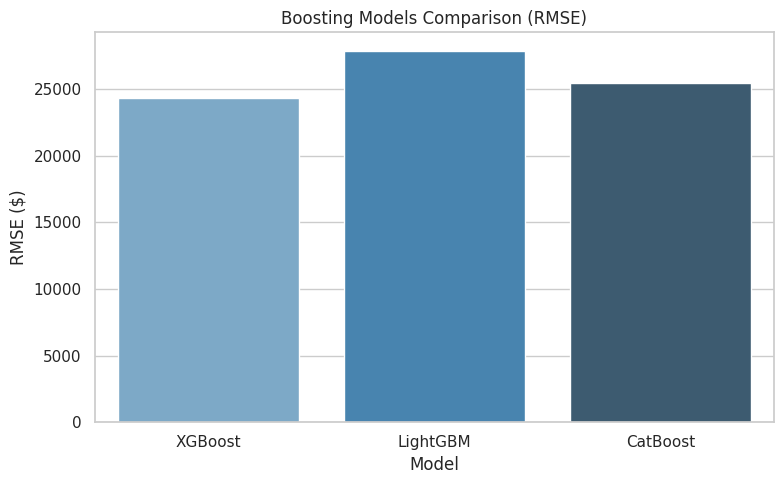

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=boosting_metrics, x="Model", y="RMSE", palette="Blues_d", ax=ax)
ax.set_title("Boosting Models Comparison (RMSE)")
ax.set_ylabel("RMSE ($)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_boosting_rmse_comparison.png", dpi=150)
plt.show()

In [9]:
# --- Export everything Role D needs ---
np.save(RESULTS_DIR / "y_pred_xgb.npy", y_pred_xgb)
np.save(RESULTS_DIR / "y_pred_lgb.npy", y_pred_lgb)
np.save(RESULTS_DIR / "y_pred_cb.npy", y_pred_cb)

joblib.dump(xgb_model, RESULTS_DIR / "xgb_model.joblib")
joblib.dump(lgb_model, RESULTS_DIR / "lgb_model.joblib")
joblib.dump(cb_model, RESULTS_DIR / "cb_model.joblib")

X_train_final.to_csv(RESULTS_DIR / "X_train_final.csv", index=False)
X_test_final.to_csv(RESULTS_DIR / "X_test_final.csv", index=False)
y_train_raw.to_csv(RESULTS_DIR / "y_train_final.csv", index=False)
y_test.to_csv(RESULTS_DIR / "y_test.csv", index=False)

preprocessing_log = pd.DataFrame([
    {
        "Decision": "Outlier removal",
        "Choice": f"Dropped {len(removed_idx)} training row(s) flagged by Role B (GrLivArea/SalePrice outliers)",
        "Reason": "Known Ames data-quirk outliers distort linear and boosting fits alike",
    },
    {
        "Decision": "Quality ordinal encoding",
        "Choice": f"Mapped {qual_cols} to Ex=5..Po=1 by VALUE, not by column name",
        "Reason": "Preserves ordinal information; avoids corrupting Condition1/2/SaleCondition, which share \"Cond\" in the name but are not ratings",
    },
    {
        "Decision": "Numeric imputation",
        "Choice": "Median, fit on train only",
        "Reason": "Robust to skew; leakage-safe",
    },
    {
        "Decision": "Categorical imputation + encoding",
        "Choice": "Most-frequent impute + OneHotEncoder(handle_unknown=\"ignore\")",
        "Reason": "Leakage-safe; unseen categories at test/deployment time don\'t crash the pipeline",
    },
    {
        "Decision": "Feature engineering",
        "Choice": "Added TotalSF, HouseAge, RemodAge, TotalBath, WasRemodeled",
        "Reason": f"Ablation showed test RMSE improved from ${rmse_without_fe:,.0f} to ${rmse_with_fe:,.0f}",
    },
    {
        "Decision": "Scaling",
        "Choice": "Not applied in this pipeline (tree/boosting models are scale-invariant)",
        "Reason": "Role A\'s Linear Regression pipeline applies its own StandardScaler separately",
    },
])
preprocessing_log.to_csv(RESULTS_DIR / "03_preprocessing_feature_log.csv", index=False)

print("Notebook 03 complete. Artifacts saved to results/:")
print("- shared_preprocessor.joblib (the pipeline itself)")
print("- X_train_final.csv, X_test_final.csv, y_train_final.csv, y_test.csv")
print("- xgb_model.joblib, lgb_model.joblib, cb_model.joblib")
print("- y_pred_xgb.npy, y_pred_lgb.npy, y_pred_cb.npy")
print("- 03_boosting_metrics.csv, 03_feature_ablation.csv, 03_preprocessing_feature_log.csv")

Notebook 03 complete. Artifacts saved to results/:
- shared_preprocessor.joblib (the pipeline itself)
- X_train_final.csv, X_test_final.csv, y_train_final.csv, y_test.csv
- xgb_model.joblib, lgb_model.joblib, cb_model.joblib
- y_pred_xgb.npy, y_pred_lgb.npy, y_pred_cb.npy
- 03_boosting_metrics.csv, 03_feature_ablation.csv, 03_preprocessing_feature_log.csv
